# Apophis — GrAL ereduarekin

ASSIST-en `Apophis.ipynb`-ren baliokidea, baina **nire GrAL ereduarekin**: IRKGL16 integratzailea,
GR_SIMPLE (Damour-Deruelle) + harmonikoak (Eguzki J2, Lurra J2/J3/J4) + 16 asteroide + Yarkovsky.

Apophis-ek Lurrarekiko hurbilketa izango du **2029-04-13an**; hemen 2029-01etik 2030-01-01era integratzen da.

In [1]:
using Pkg; Pkg.activate(joinpath(@__DIR__, ".."))
using GravitationSimulation, LittleEphemeris
using SciMLBase, IRKGaussLegendre
using SPICE, LinearAlgebra, Printf, Plots

const AU2KM = 149_597_870.7
const DAY2S = 86_400.0
DATA = joinpath(@__DIR__, "..", "data")
furnsh(joinpath(DATA,"naif0012.tls"), joinpath(DATA,"de440.bsp"), joinpath(DATA,"sb441-n16.bsp"))
println("Julia $(VERSION) — prest.")

  Activating 

Julia 1.12.5 — prest.


project at `~/Documentos/Ingenieritza_Informatikoa/GrAL/GrAL_github`


## 1. Hasierako baldintzak (Holman et al. 2023)

Heliozentriko (AU, AU/egun) → barizentriko (km, km/s).

In [2]:
const JD_REF = 2_451_545.0
t_initial = 2.4621385359989386e6 - JD_REF
t_final   = 2.4625030372426095e6 - JD_REF   # 2030-01-01
const et_0   = t_initial * DAY2S
const et_end = t_final   * DAY2S

helio_pos = [-5.5946538550488512e-1,  8.5647564757574512e-1,  3.0415066217102493e-1]
helio_vel = [-1.3818324735921638e-2, -6.0088275597939191e-3, -2.5805044631309632e-3]
sun_st, _ = spkez(Int32(10), et_0, "J2000", "NONE", Int32(0))
const u0 = [helio_pos[1]*AU2KM+sun_st[1], helio_pos[2]*AU2KM+sun_st[2], helio_pos[3]*AU2KM+sun_st[3],
            helio_vel[1]*AU2KM/DAY2S+sun_st[4], helio_vel[2]*AU2KM/DAY2S+sun_st[5], helio_vel[3]*AU2KM/DAY2S+sun_st[6]]
@printf("t_initial = %.4f egun | t_final = %.4f egun (%.1f egun)\n", t_initial, t_final, t_final-t_initial)

t_initial = 10593.5360 egun | t_final = 10958.0372 egun (364.5 egun)


## 2. Eredua: gorputzak, GM-ak eta indarrak

In [3]:
# Setup sinplifikatua: GM-ak ID-etatik (planet_system), 11 planeta + 16 asteroide.
# GM-ak gm_de440.tpc-tik (bodvrd) datoz; ez da balioak eskuz idatzi behar.
tiv = (et_0 - 5*DAY2S, et_end + 5*DAY2S)
ids, mus, bodies = planet_system(tiv; datadir=DATA, asteroids=true,
                                 coeffs_json=joinpath(DATA,"coeffs_apophis.json"),
                                 coeffs_csv=joinpath(DATA,"coeffs_apophis.csv"))

# GrAL eredu OSOA: GR_EIH + harmonikoak + 16 asteroide + Yarkovsky
p = (mus=mus, ids=ids, bodies=bodies,
     physics=(; DEFAULT_PHYSICS..., yarkovsky=true, A1=5.0e-13, A2=-2.9e-14, A3=0.0))
println("Eredua prest: $(length(ids)) gorputz + Yarkovsky.")

Eredua prest: 27 gorputz + Yarkovsky.


## 3. Integrazioa (2029-01 → 2030-01-01)

In [4]:
N = 10_000
times = collect(range(et_0, et_end, length=N))
print("Integratzen... ")
@time sol = solve(ODEProblem(f_master!, u0, (et_0, et_end), p), IRKGL16();
                  reltol=1e-12, abstol=1e-12, saveat=times)

# Apophis (AU) eta Lurra (AU, SPICE bidez), denbora-puntu berdinetan
apophis = hcat([u[1:3] for u in sol.u]...)' ./ AU2KM
earth   = hcat([spkez(Int32(399), t, "J2000", "NONE", Int32(0))[1][1:3] for t in sol.t]...)' ./ AU2KM
println("$(length(sol.u)) puntu.")

Integratzen...   3.236058 seconds (12.68 M allocations: 501.246 MiB, 3.50% gc time, 96.34% compilation time: 1% of which was recompilation)
10000 puntu.


## 4. Azken posizioa JPL Small-Body kodearekin alderatu

### Oharrak eta hobekuntzak (Lessons Learned)
1. **Regression tests against ASSIST forces**. This is the #1 lesson from today — the sign bug lived in four functions, undetected, for who knows how long. A small test suite that checks each force component (Newton, GR, J2/J3/J4, Yarkovsky) against ASSIST for a fixed position — the "ratio should be +1" check we did by hand — would have caught it instantly. Cheap, high-value.
2. **Consolidate the duplicated force code**. The bug existed in four near-identical harmonics blocks (`f_master!`, `f_all_rel_J!`, `f_all_rel_J2_Sun!`, …). That duplication is why it could hide. One parametrized force function (which `f_master!` already mostly is) would prevent the variants from drifting apart.
3. **GR_EIH**. The remaining ~30 km floor is the GR_SIMPLE-vs-GR_EIH model choice. Implementing full Einstein-Infeld-Hoffmann N-body relativity is the next physics step if you want to close the gap to ASSIST entirely (~4 m at the encounter, but it's the dominant residual).
4. **Move from deterministic to probabilistic**. This is the scientifically interesting direction. We showed the year-end position is meaningless at the metre level — the encounter is a chaotic amplifier. The right framing is uncertainty propagation: push a covariance/particle cloud through the encounter and look at the b-plane and gravitational keyholes. That's what actual impact-risk assessment does, and GrAL is now accurate enough to attempt it.

In [5]:
# 1. Apophis-en azken posizio heliozentrikoa (JPL Horizons, AU unitatetan)
jpl_helio_pos = [1.7028330901729331e-2, 1.2193934090901304e0, 4.7823589236374386e-1]

# 2. Eguzkiaren posizio barizentrikoa t_final uneari dagokionez (SPICE bidez, km-tik AU-ra pasatuz)
sun_state_final, _ = spkez(Int32(10), et_end, "J2000", "NONE", Int32(0))
sun_bary_pos = sun_state_final[1:3] ./ AU2KM

# 3. Barizentrikora bihurtu (Heliozentrikoa + Eguzkia = Barizentrikoa)
jpl_bary = jpl_helio_pos .+ sun_bary_pos

# Orain diferentzia kalkula dezakezu aurretik zenuen bezala:
Δ_jpl = norm(apophis[end,:] .- jpl_bary) * AU2KM
@printf("GrAL azken posizioa (AU): [%.10f, %.10f, %.10f]\n", apophis[end,:]...)
@printf("JPL Small-Body  (AU):     [%.10f, %.10f, %.10f]\n", jpl_bary...)
@printf("\nDiferentzia GrAL vs JPL: %.2f km\n", Δ_jpl)

GrAL azken posizioa (AU): [0.0175755513, 1.2196672867, 0.4783965177]
JPL Small-Body  (AU):     [0.0175755421, 1.2196672850, 0.4783965165]

Diferentzia GrAL vs JPL: 1.41 km


## 5. Orbitak (Apophis eta Lurra)

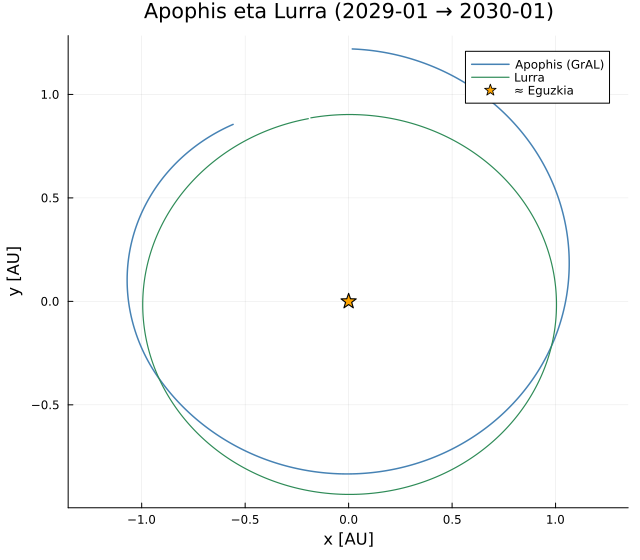

In [6]:
plt = plot(apophis[:,1], apophis[:,2], label="Apophis (GrAL)", lw=1.5, color=:steelblue,
    xlabel="x [AU]", ylabel="y [AU]", title="Apophis eta Lurra (2029-01 → 2030-01)",
    aspect_ratio=:equal, size=(640,560), legend=:topright)
plot!(plt, earth[:,1], earth[:,2], label="Lurra", lw=1.2, color=:seagreen)
scatter!(plt, [0.0],[0.0], marker=:star5, color=:orange, markersize=8, label="≈ Eguzkia")
display(plt)

## 6. Gertutasun-unea — Lurrarekiko erreferentzian (2029-04-13)

Lurra erdian (eskalan), Apophis-en ibilbidea inguruan, `0.001 AU` unitateetan.

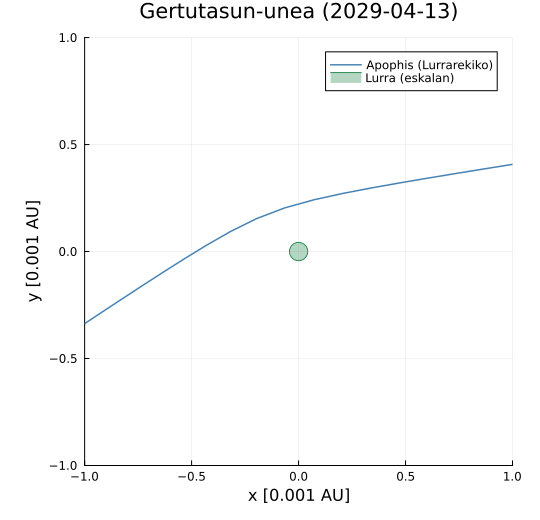

In [7]:
rel = (apophis .- earth) .* 1e3   # 0.001 AU unitateak
pz = plot(rel[:,1], rel[:,2], label="Apophis (Lurrarekiko)", lw=1.5, color=:steelblue,
    xlabel="x [0.001 AU]", ylabel="y [0.001 AU]", title="Gertutasun-unea (2029-04-13)",
    aspect_ratio=:equal, xlims=(-1,1), ylims=(-1,1), size=(540,520), legend=:topright)
θ = range(0, 2π, length=100)
plot!(pz, 4.2587571e-2 .* cos.(θ), 4.2587571e-2 .* sin.(θ),
      label="Lurra (eskalan)", color=:seagreen, fill=true, fillalpha=0.35)
display(pz)